# Pointing Corrections

Demonstration of `events.pointing_corrections` (see `configs/crab.yaml`): how `heap.events` corrects each camera's offset from
where it should be pointing, so images from different telescopes can be intersected for stereo reconstruction.

Every telescope in a run points at the run's commanded wobble position: Ekos aligns each one to it, then guides
(`heap.events.wobble_pointings()`). So each run has one pointing, shared by every telescope, and each image's camera
coordinates (`x_c`, `y_c`, deg) are relative to it, up to that camera's own offset. `load_camera_frame()` subtracts that offset,
the **pointing correction**, per night, telescope and flip side (after postflip images are rotated 180 deg to the preflip orientation).

A pointing correction $(dx, dy)$ in deg is where a sky position **appears** in the camera minus where it **should** appear from the
run's pointing (`heap.significance.make_wcs()`), with +x east and +y south. For example, if the run points at the Crab, it should
be at (0, 0); if it appears at (1, 1), 1 deg east and 1 deg south, the correction is (1, 1). In a wobble N run the Crab should be
at (0, 0.5) instead. Only the centroid moves: `phi`, `length` and `width` don't change.

We use toy images with known offsets, so we can check that everything is put back.

## Imports

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import astropy.units as u

from heap import events as ev
from heap import toy_events as toy
from heap.reconstruction import reconstruct_directions
from heap.significance import make_wcs
from heap.sources import SOURCES

## Toy Data

In [2]:
DATE = "toy"
SOURCE = SOURCES["Crab"]
WOBBLE = toy.wobble_pointings(SOURCE, 0.5, directions=("N",))["N"] # both runs' pointing, shared by every telescope
TELESCOPES = ["Winter", "Fern", "Heli", "Gattini"]
N_SHOWERS = 500 # per run

One preflip and one postflip run. Flip sides and runs only come from the run folders' start times (`heap.events.flip_side_of()`,
`run_of()`), so here they are just names, with no data in them.

In [3]:
RUN_STARTS = {"preflip": "2026-09-17T06:00:00", "postflip": "2026-09-17T09:00:00"} # UTC
RUNS = {side: [Path(f"obs_Crab.start_{start}Z.runtype_sci-obs.pffd")] for side, start in RUN_STARTS.items()}

Each camera's offset from the run's pointing, in the config's format `{(date, telescope, flip_side): (dx, dy)}` (what
`heap.config.load_analysis_config()` turns the YAML into):

In [4]:
OFFSETS = {
    (DATE, "Winter", "preflip"): (0.10, 0.05),
    (DATE, "Fern", "preflip"): (0.25, -0.15),
    (DATE, "Fern", "postflip"): (-0.10, 0.20),
    (DATE, "Heli", "preflip"): (-0.30, 0.10),
    (DATE, "Heli", "postflip"): (0.15, 0.25),
    (DATE, "Gattini", "preflip"): (0.05, 0.30),
    (DATE, "Gattini", "postflip"): (0.20, -0.10),
}

The source is 0.5 deg south of the pointing (camera coordinates: deg from the pointing, +x east, +y south):

In [5]:
SOURCE_XY = np.array(make_wcs(WOBBLE).wcs_world2pix(SOURCE.ra.deg, SOURCE.dec.deg, 1))
print(f"source at x = {SOURCE_XY[0]:.3f}, y = {SOURCE_XY[1]:.3f} deg")

source at x = -0.000, y = 0.500 deg


`simulate_images()` makes toy gamma-ray showers from the source, each seen by every telescope. Each image has its centroid 0.5-2 deg from the source (in camera coordinates relative to the pointing), in a random direction, and its axis pointing back
at the source (to within a few deg). Then, like a real camera:
1. the image is shifted by that camera's offset, for the run's flip side
2. postflip images are rotated 180 deg (that's what the camera sees after the flip; `load_camera_frame()` rotates them back)

The images are written as one `<source_slug>.npz` per telescope, like `heap.process_dataset.process_dataset()` does, so
`load_camera_frame()` reads them as it would real data. `miss`, `distance` and `alpha` aren't used here.

In [6]:
def simulate_images(rng):
    images = {tel: [] for tel in TELESCOPES}
    for side, start in RUN_STARTS.items():
        timestamps = np.sort(pd.Timestamp(start, tz="UTC").timestamp() + rng.uniform(0, 3600, N_SHOWERS))
        for tel in TELESCOPES:
            n = N_SHOWERS
            r = rng.uniform(0.5, 2.0, n)
            psi = rng.uniform(0, 360, n)
            x = SOURCE_XY[0] + r*np.cos(np.deg2rad(psi))
            y = SOURCE_XY[1] + r*np.sin(np.deg2rad(psi))
            phi = psi + rng.normal(0, 3, n) # image axis through the source

            dx, dy = OFFSETS.get((DATE, tel, side), (0, 0))
            x, y = x + dx, y + dy
            if side == "postflip":
                x, y, phi = -x, -y, phi + 180

            images[tel].append(pd.DataFrame({
                "Timestamp": timestamps, "x_c": x, "y_c": y, "phi": phi % 360,
                "size": rng.lognormal(np.log(500), 0.5, n), "N_pix": 10,
                "length": rng.uniform(0.4, 0.8, n), "width": rng.uniform(0.15, 0.3, n),
                "miss": np.nan, "distance": np.nan, "alpha": np.nan,
            }))

    tmp = Path(tempfile.mkdtemp())
    paths = {}
    for tel, parts in images.items():
        df = pd.concat(parts, ignore_index=True)
        df.insert(0, "Event", np.arange(len(df)))
        paths[tel] = tmp / f"{tel}.npz"
        np.savez(paths[tel], **{col: df[col].to_numpy() for col in df})
    return paths


npz_paths = simulate_images(np.random.default_rng(0))

## Loading

`load_camera_frame()` two ways:
- **as recorded**: each telescope's images as its camera recorded them, measured from its own camera center
- **pointing correction**: pointing corrections subtracted, so measured from the run's pointing, as `load_camera_frames()` does

It takes one telescope's `{flip_side: (dx, dy)}`; `load_camera_frames()` picks those out of the config's dict for each night and
telescope, as below.

In [7]:
def load(corrections):
    loaded = {}
    for tel in TELESCOPES:
        tel_corrections = {side: offset for (d, t, side), offset in corrections.items() if d == DATE and t == tel}
        loaded[tel] = ev.load_camera_frame(npz_paths[tel], tel, RUNS, rotate_postflip=True, pointing_corrections=tel_corrections)
    return loaded


images = {
    "as recorded": load({}),
    "pointing correction": load(OFFSETS),
}

`x_shift`, `y_shift` are how far each centroid moved from its position in the (rotated) camera image: minus the config's offset,
for each telescope and flip side (postflip in the rotated orientation):

In [8]:
shift = pd.concat(images["pointing correction"].values()).groupby(["Telescope", "FlipSide"])[["x_shift", "y_shift"]].mean().round(3)
shift["config (dx, dy)"] = [OFFSETS.get((DATE, tel, side), (0, 0)) for tel, side in shift.index]
shift

x_shift  y_shift config (dx, dy)
Telescope FlipSide                                  
Fern      postflip     0.10    -0.20     (-0.1, 0.2)
          preflip     -0.25     0.15   (0.25, -0.15)
Gattini   postflip    -0.20     0.10     (0.2, -0.1)
          preflip     -0.05    -0.30     (0.05, 0.3)
Heli      postflip    -0.15    -0.25    (0.15, 0.25)
          preflip      0.30    -0.10     (-0.3, 0.1)
Winter    postflip     0.00     0.00          (0, 0)
          preflip     -0.10    -0.05     (0.1, 0.05)

In [9]:
for tel in TELESCOPES:
    a, b = images["as recorded"][tel], images["pointing correction"][tel]
    assert (a[["phi", "length", "width", "size"]] == b[["phi", "length", "width", "size"]]).all().all()

Every telescope sees every toy shower, so an image's `ImageIndex` is its shower number, and we use it as `Event` (on real data,
`heap.events.build_events()` matches images into events by time):

In [10]:
def as_events(loaded):
    e = pd.concat(loaded.values(), ignore_index=True)
    e.insert(0, "Event", e.ImageIndex)
    e.insert(1, "Date", DATE) # build_array_events() adds Date
    return e


events = {label: as_events(loaded) for label, loaded in images.items()}

## One Shower

Each telescope's Hillas ellipse and image axis for one preflip and one postflip shower, relative to the run's pointing (east
left, north up). As recorded, each axis passes through the source shifted by that camera's offset, so the axes miss each other.
With the pointing correction, they cross near the source: like real images, each toy image's axis is off by a few deg
(`simulate_images()`), so an axis far from the source can miss it by a few tenths of a deg.

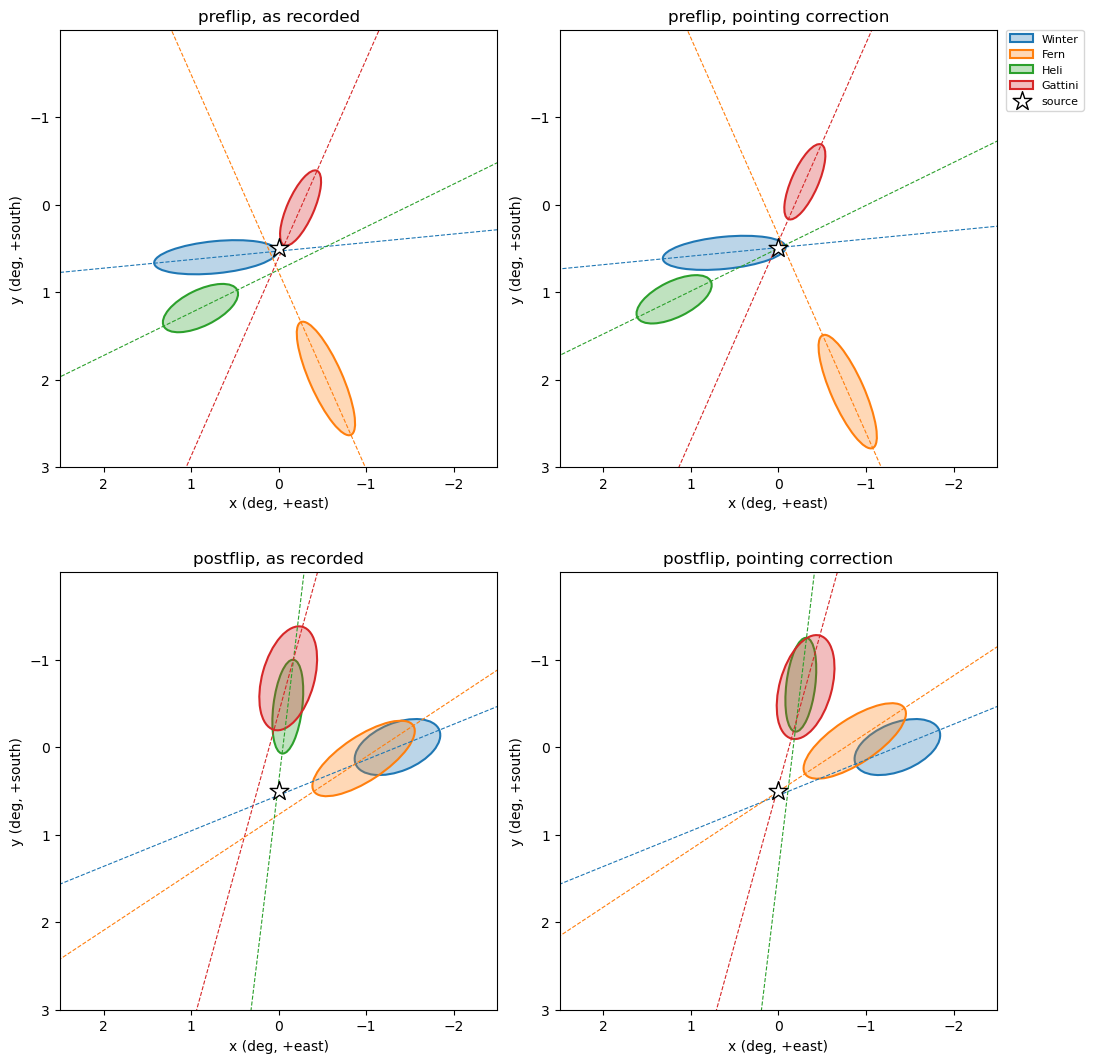

In [11]:
COLORS = {"Winter": "tab:blue", "Fern": "tab:orange", "Heli": "tab:green", "Gattini": "tab:red"}


def plot_shower(ax, event, title):
    for _, tel in event.iterrows():
        ev.draw_hillas(ax, tel, COLORS[tel.Telescope], fill_alpha=0.3)
    xy = SOURCE_XY
    ax.scatter(*xy, marker="*", facecolor="white", edgecolor="k", s=200, zorder=3, label="source")
    ax.set_xlim(xy[0] + 2.5, xy[0] - 2.5) # +x is east and +y south: reversed for east left, north up
    ax.set_ylim(xy[1] + 2.5, xy[1] - 2.5)
    ax.set_aspect("equal")
    ax.set(xlabel="x (deg, +east)", ylabel="y (deg, +south)", title=title)


fig, axs = plt.subplots(2, 2, figsize=(11, 11))
for row, side in zip(axs, ["preflip", "postflip"]):
    e = events["pointing correction"]
    event = e[e.FlipSide == side].Event.iloc[0]
    for ax, (label, e) in zip(row, events.items()):
        plot_shower(ax, e[e.Event == event], f"{side}, {label}")
legend = {label: h for ax in axs[:, -1] for h, label in zip(*ax.get_legend_handles_labels())} # every telescope, from both rows
axs[0, -1].legend(legend.values(), legend.keys(), fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()

## Reconstruction

`heap.reconstruction.reconstruct_directions()` on every event, then each one's distance $\theta$ from the source.

In [12]:
def reconstruct(e):
    directions = reconstruct_directions(e)
    directions["FlipSide"] = directions.Event.map(e.groupby("Event").FlipSide.first())
    directions["theta"] = np.hypot(directions.Xoffset - SOURCE_XY[0], directions.Yoffset - SOURCE_XY[1])
    return directions


directions = {label: reconstruct(e) for label, e in events.items()}

as recorded          preflip : median offset from the source (+0.026, +0.072) deg, 68% containment 0.259 deg
as recorded          postflip: median offset from the source (+0.076, +0.088) deg, 68% containment 0.223 deg
pointing correction  preflip : median offset from the source (+0.002, +0.000) deg, 68% containment 0.083 deg
pointing correction  postflip: median offset from the source (+0.006, +0.001) deg, 68% containment 0.086 deg


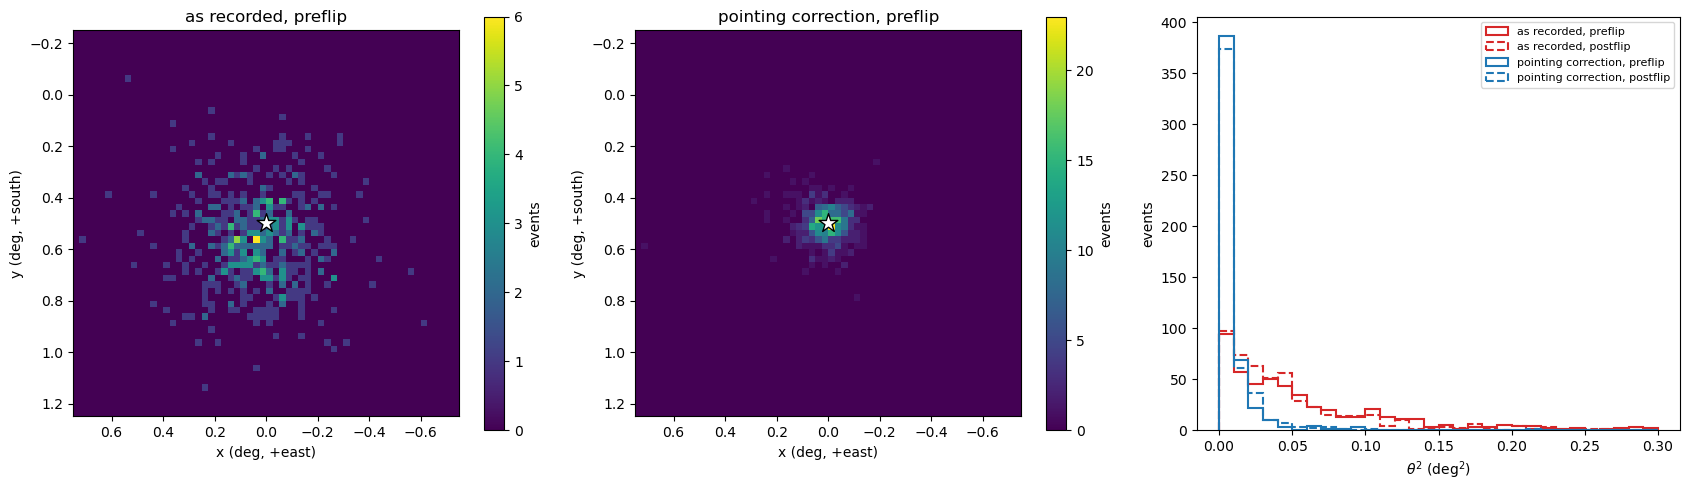

In [13]:
RANGE = 0.75 # deg from the source
fig, axs = plt.subplots(1, 3, figsize=(17, 5))
for ax, (label, d) in zip(axs, directions.items()):
    d = d[d.FlipSide == "preflip"]
    xy = SOURCE_XY
    h = ax.hist2d(d.Xoffset, d.Yoffset, bins=60, range=[[xy[0] - RANGE, xy[0] + RANGE], [xy[1] - RANGE, xy[1] + RANGE]], cmap="viridis")
    ax.scatter(*xy, marker="*", facecolor="white", edgecolor="k", s=200)
    ax.set_xlim(xy[0] + RANGE, xy[0] - RANGE)
    ax.set_ylim(xy[1] + RANGE, xy[1] - RANGE)
    ax.set_aspect("equal")
    ax.set(xlabel="x (deg, +east)", ylabel="y (deg, +south)", title=f"{label}, preflip")
    fig.colorbar(h[3], ax=ax, label="events")

bins = np.linspace(0, 0.3, 31)
for (label, d), color in zip(directions.items(), ["tab:red", "tab:blue"]):
    for side, ls in [("preflip", "-"), ("postflip", "--")]:
        axs[2].hist(d[d.FlipSide == side].theta**2, bins=bins, histtype="step", ls=ls, lw=1.5, color=color, label=f"{label}, {side}")
axs[2].set(xlabel=r"$\theta^2$ (deg$^2$)", ylabel="events")
axs[2].legend(fontsize=8)
plt.tight_layout()

for label, d in directions.items():
    for side, g in d.groupby("FlipSide", sort=False):
        print(f"{label:20s} {side:8s}: median offset from the source ({g.Xoffset.median() - SOURCE_XY[0]:+.3f}, "
              f"{g.Yoffset.median() - SOURCE_XY[1]:+.3f}) deg, 68% containment {g.theta.quantile(0.68):.3f} deg")

With the pointing correction, the reconstructed directions are back on the source, with only the spread from the image axes'
few-deg scatter.

A shift shared by every image would leave the axes crossing at one point, just not the source: it moves the whole map rather than
blurring it. Different offsets per camera blur it, which is what the pointing corrections remove.

## Postflip Sign

`load_camera_frame()` rotates postflip images 180 deg first, then subtracts the postflip offset **as given**: it does **not**
rotate the offset. So the postflip offset in the config must already be in rotated (preflip-orientation) coordinates, either:
- measured on rotated images, or
- measured on **raw** postflip images (e.g. star positions in pedvar maps, which aren't rotated) and **negated by you**

The code can't tell which, and doesn't check. Entering a raw measurement without negating it doubles the postflip error instead
of removing it:

In [14]:
raw_postflip = {key: ((-dx, -dy) if key[2] == "postflip" else (dx, dy)) for key, (dx, dy) in OFFSETS.items()}
d = reconstruct(as_events(load(raw_postflip)))
for side, g in d.groupby("FlipSide", sort=False):
    print(f"{side:8s}: 68% containment {g.theta.quantile(0.68):.3f} deg")

preflip : 68% containment 0.083 deg
postflip: 68% containment 0.429 deg


## Summary

- every telescope in a run shares the run's pointing, its commanded wobble position (`heap.events.wobble_pointings()`)
- `pointing_corrections[(date, telescope, flip_side)] = (dx, dy)`: where a sky position appears in that camera minus where the run's
  pointing puts it, in deg; subtracted from `x_c`, `y_c` in `load_camera_frame()`, so only centroids move
- postflip offsets must already be in rotated (preflip-orientation) coordinates; the code doesn't rotate them. Negate offsets
  measured on raw postflip images yourself